# EDA — Game-Predictor

Three visuals from the Steam Web API DuckDB database.

In [16]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
})

In [17]:
STEAM_DB_PATH = "steam_data.duckdb"

steam_con = duckdb.connect(STEAM_DB_PATH, read_only=True)

## Data loading

In [18]:
achievements_df = steam_con.execute("""
    SELECT g.name AS game,
           a.name AS achievement,
           CAST(a.percent AS DOUBLE) AS percent
    FROM achievements a
    JOIN games g ON a.appid = g.appid
""").fetchdf()

print(f"{len(achievements_df)} achievements across {achievements_df['game'].nunique()} games")
achievements_df.head()

374 achievements across 5 games


,game,achievement,percent
0,Stellaris,achievement_economy_1,37.7
1,Stellaris,achievement_colonize,34.3
2,Stellaris,achievement_economy_2,33.9
3,Stellaris,achievement_rare,29.1
4,Stellaris,achievement_survey,23.8


In [19]:
player_counts_df = steam_con.execute("""
    SELECT g.name AS game,
           pc.player_count,
           pc.fetched_at
    FROM player_counts pc
    JOIN games g ON pc.appid = g.appid
    ORDER BY pc.fetched_at
""").fetchdf()

player_counts_df["fetched_at"] = pd.to_datetime(player_counts_df["fetched_at"])

print(f"{len(player_counts_df)} snapshots | {player_counts_df['fetched_at'].min()} to {player_counts_df['fetched_at'].max()}")
player_counts_df.head()

11 snapshots | 2026-04-10 05:41:36.752970+00:00 to 2026-04-10 06:06:53.948798+00:00


,game,player_count,fetched_at
0,Stellaris,9994,2026-04-10 05:41:36.752970+00:00
1,Stellaris,9994,2026-04-10 05:42:20.024060+00:00
2,No Man's Sky,9470,2026-04-10 05:42:21.798122+00:00
3,Apex Legends,99004,2026-04-10 05:42:23.021877+00:00
4,Stardew Valley,55142,2026-04-10 05:42:24.417733+00:00


In [20]:
GAME_ORDER = ["Stellaris", "No Man's Sky", "Apex Legends",
              "Stardew Valley", "Skyrim Special Edition"]
GAME_COLORS = {
    "Stellaris": "#E8C547",
    "No Man's Sky": "#43D9AD",
    "Apex Legends": "#E05252",
    "Stardew Valley": "#7EC8E3",
    "Skyrim Special Edition": "#B48EAD",
}
present_games = [g for g in GAME_ORDER if g in achievements_df["game"].values]

---
## Visual 1 — Achievement completion rate distributions

Faceted histogram + KDE on `achievements.percent`, one panel per game.

In [21]:
achievements_df.groupby("game")["percent"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
game,,,,,,
Apex Legends,12,30.10,30.0,10.68,14.7,46.8
No Man's Sky,27,29.25,28.8,20.92,0.8,73.2
Skyrim Special Edition,75,17.52,13.9,13.76,2.8,71.8
Stardew Valley,49,20.95,16.1,17.63,1.3,62.9
Stellaris,211,5.28,2.5,7.10,0.0,37.7


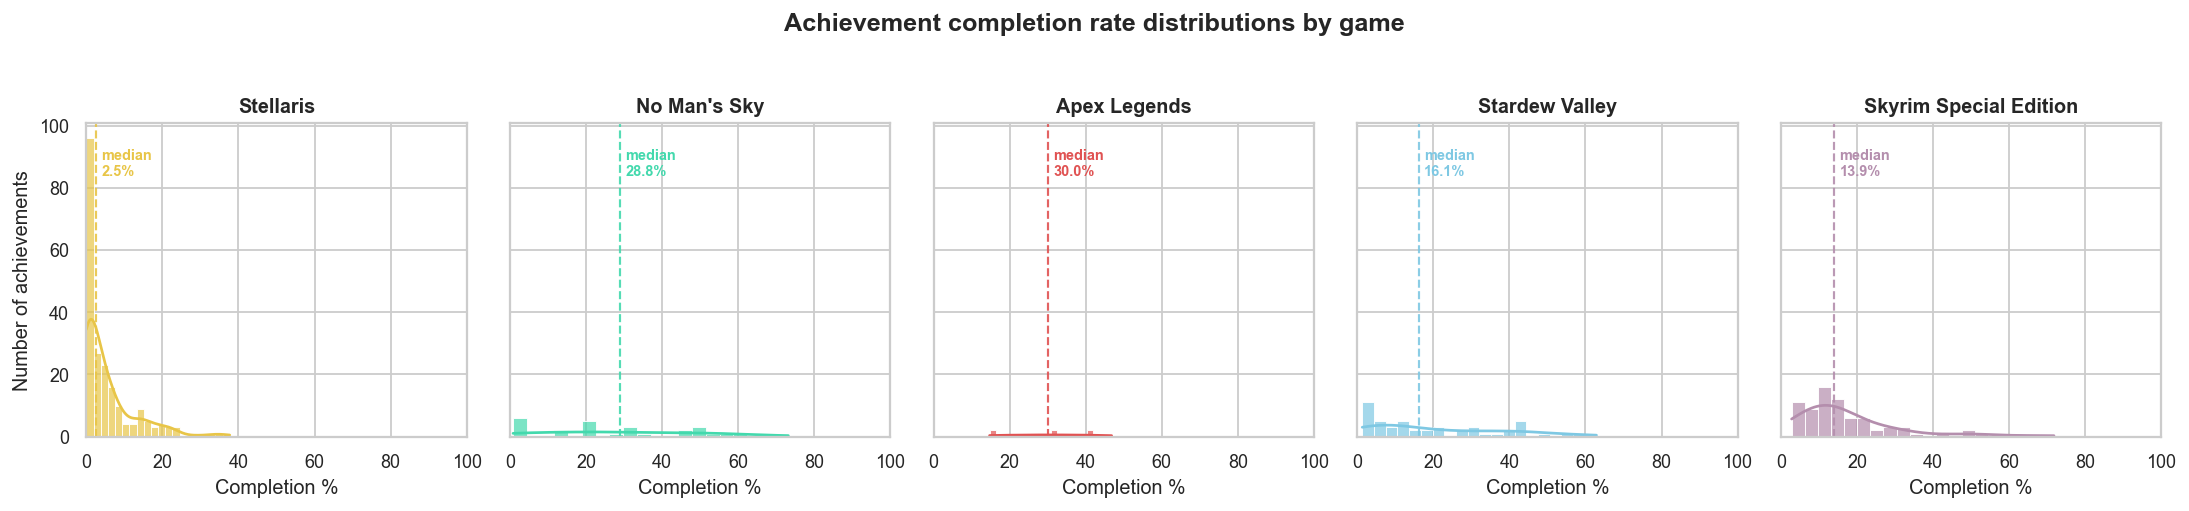

In [22]:
fig, axes = plt.subplots(1, len(present_games), figsize=(3.4 * len(present_games), 3.8),
                         sharey=True)
if len(present_games) == 1:
    axes = [axes]

for ax, game in zip(axes, present_games):
    subset = achievements_df[achievements_df["game"] == game]["percent"]
    color = GAME_COLORS.get(game, "#888888")

    sns.histplot(subset, bins=20, kde=True, color=color, edgecolor="white",
                 linewidth=0.5, alpha=0.7, ax=ax)

    med = subset.median()
    ax.axvline(med, color=color, linestyle="--", linewidth=1.2, alpha=0.9)
    ax.text(med + 1.5, ax.get_ylim()[1] * 0.92, f"median\n{med:.1f}%",
            fontsize=8, color=color, fontweight="bold", va="top")

    ax.set_title(game, fontweight="bold", fontsize=11)
    ax.set_xlabel("Completion %")
    ax.set_xlim(0, 100)

axes[0].set_ylabel("Number of achievements")
fig.suptitle("Achievement completion rate distributions by game",
             fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
plt.savefig("visual1_achievement_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

All five games are right-skewed. The degree of skew varies by genre — strategy titles concentrate in the ultra-rare band, while casual games have flatter distributions with higher medians. These shapes are potential classifier features.

---
## Visual 2 — Concurrent player counts by game

Horizontal bar chart of mean `player_counts.player_count` per game from the append-only snapshots.

In [23]:
pc_summary = player_counts_df.groupby("game")["player_count"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(0).astype(int)
pc_summary["cv_pct"] = (pc_summary["std"] / pc_summary["mean"] * 100).round(1)
pc_summary.sort_values("mean", ascending=False)

,count,mean,median,std,min,max,cv_pct
game,,,,,,,
Apex Legends,2,99142,99142,196,99004,99281,0.2
Stardew Valley,2,54250,54250,1261,53359,55142,2.3
Skyrim Special Edition,2,14844,14844,331,14610,15078,2.2
Stellaris,3,9930,9994,111,9801,9994,1.1
No Man's Sky,2,9350,9350,170,9230,9470,1.8


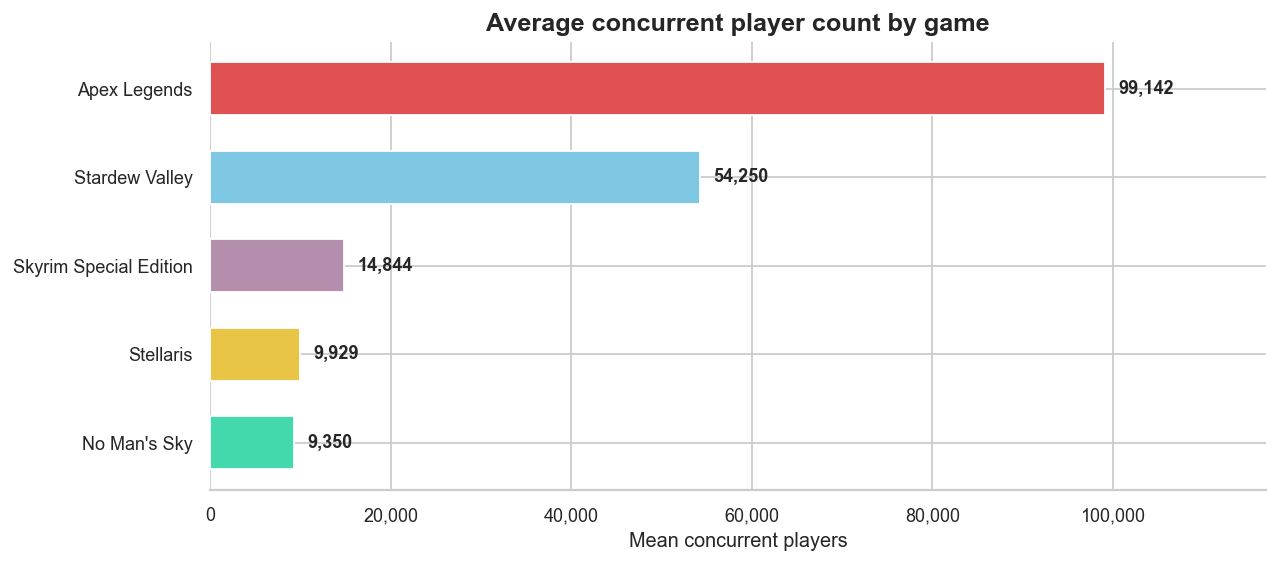

In [24]:
mean_counts = (
    player_counts_df.groupby("game")["player_count"]
    .mean()
    .reindex(present_games)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 4.5))

bars = ax.barh(
    mean_counts.index,
    mean_counts.values,
    color=[GAME_COLORS.get(g, "#888888") for g in mean_counts.index],
    edgecolor="white",
    height=0.6,
)

for bar, val in zip(bars, mean_counts.values):
    ax.text(val + mean_counts.max() * 0.015, bar.get_y() + bar.get_height() / 2,
            f"{int(val):,}", va="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Mean concurrent players")
ax.set_title("Average concurrent player count by game",
             fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(0, mean_counts.max() * 1.18)

sns.despine(left=True)
ax.tick_params(left=False)
fig.tight_layout()
plt.savefig("visual2_player_counts.png", dpi=200, bbox_inches="tight")
plt.show()

Apex dominates by roughly an order of magnitude. The 200-per-game scraping target neutralizes this population imbalance for training, but the disparity is worth noting as a data provenance detail.

---
## Visual 3 — News article volume by game and feed source

Stacked bar chart from the `news` table showing article counts per game, broken down by `feedlabel`.

In [25]:
news_df = steam_con.execute("""
    SELECT g.name AS game,
           n.feedlabel,
           n.gid
    FROM news n
    JOIN games g ON n.appid = g.appid
""").fetchdf()

print(f"{len(news_df)} articles across {news_df['game'].nunique()} games")
print(f"Feed sources: {news_df['feedlabel'].nunique()} unique labels")
news_df.head()

500 articles across 5 games
Feed sources: 10 unique labels


,game,feedlabel,gid
0,Stellaris,PCGamesN,1829528821308307
1,Stellaris,Community Announcements,1829528821306296
2,Stellaris,Community Announcements,1828894815557067
3,Stellaris,Community Announcements,1828894815554420
4,Stellaris,Community Announcements,1828441623112062


In [26]:
# Keep top feed sources, bucket the rest into "Other"
top_feeds = news_df["feedlabel"].value_counts().head(4).index.tolist()
news_df["feed_group"] = news_df["feedlabel"].where(
    news_df["feedlabel"].isin(top_feeds), "Other"
)

pivot = (
    news_df.groupby(["game", "feed_group"]).size()
    .unstack(fill_value=0)
    .reindex(present_games)
)

pivot

feed_group,Community Announcements,Gamemag.ru,Other,PC Gamer,PCGamesN
game,,,,,
Stellaris,83,0,2,2,13
No Man's Sky,24,2,31,22,21
Apex Legends,97,0,3,0,0
Stardew Valley,12,0,14,57,17
Skyrim Special Edition,7,25,2,58,8


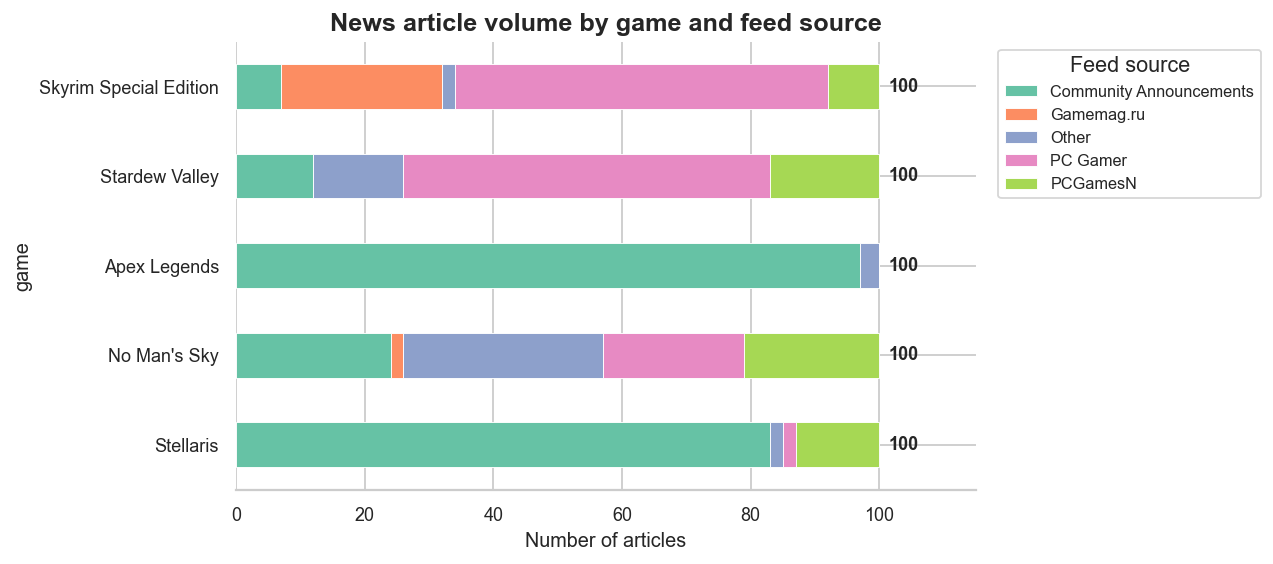

In [27]:
feed_colors = sns.color_palette("Set2", n_colors=len(pivot.columns))

fig, ax = plt.subplots(figsize=(10, 4.5))

pivot.plot.barh(stacked=True, ax=ax, color=feed_colors, edgecolor="white",
                linewidth=0.5)

# Add total count at bar end
totals = pivot.sum(axis=1)
for i, (game, total) in enumerate(totals.items()):
    ax.text(total + totals.max() * 0.015, i,
            str(int(total)), va="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Number of articles")
ax.set_title("News article volume by game and feed source",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, totals.max() * 1.15)
ax.legend(title="Feed source", bbox_to_anchor=(1.02, 1), loc="upper left",
          frameon=True, edgecolor="#CCCCCC", fontsize=9)

sns.despine(left=True)
ax.tick_params(left=False)
fig.tight_layout()
plt.savefig("visual3_news_volume.png", dpi=200, bbox_inches="tight")
plt.show()

Article volume varies substantially across games. Games with active update cycles generate more community announcements. The feed source breakdown shows which outlets cover each title — useful context for understanding the text data available for NLP feature extraction.

In [28]:
steam_con.close()